In [1]:
# Import the necessary library
import pypdf

# --- Configuration ---
# 1. Set the name of your input PDF file
input_pdf_path = 'peppa.pdf' 

# 2. Set the name for your new, smaller PDF file
output_pdf_path = 'split_document_pages_4_to_63.pdf'

# 3. Define the page range you want to extract (page 4 to page 63)
# IMPORTANT: Python indexing starts at 0, so Page 1 is index 0.
# To get Page 4, you need index 3.
# To get Page 63, you need index 62.
start_page = 4  # The human-readable start page number
end_page = 63   # The human-readable end page number


# --- PDF Splitting Logic ---
try:
    # Create a PDF reader and writer object
    reader = pypdf.PdfReader(input_pdf_path)
    writer = pypdf.PdfWriter()

    # Loop through the desired pages and add them to the writer
    # We use (start_page - 1) to (end_page) because the range's second number is exclusive.
    for page_num in range(start_page - 1, end_page):
        writer.add_page(reader.pages[page_num])

    # Write the new content to the output PDF file
    with open(output_pdf_path, 'wb') as output_file:
        writer.write(output_file)

    print(f"✅ Successfully created '{output_pdf_path}'")
    print(f"It contains pages {start_page} through {end_page} from the original file.")

except FileNotFoundError:
    print(f"❌ ERROR: The file '{input_pdf_path}' was not found.")
    print("Please make sure the PDF file is in the same directory as your notebook, or provide the full path.")
except IndexError:
    print(f"❌ ERROR: The PDF does not have {end_page} pages. Please check your page range.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")



ModuleNotFoundError: No module named 'pypdf'

In [2]:
!pip install PyPDF2

In [35]:
from PyPDF2 import PdfReader, PdfWriter

input_path = "peppa.pdf"   # Replace with your PDF filename
output_path = "season1-4.pdf"

# Create PDF reader and writer objects
reader = PdfReader(input_path)
writer = PdfWriter()

# Extract pages 4 to 63 (PyPDF2 uses 0-based indexing: 
# Page 4 = index 3, Page 63 = index 62)
start_page = 3   # Page 4 in PDF (index 3)
end_page = 219    # Page 63 in PDF (index 62)

for page_num in range(start_page, end_page + 1):
    writer.add_page(reader.pages[page_num])

# Save the extracted pages
with open(output_path, "wb") as output_file:
    writer.write(output_file)

print(f"Success! Pages 4-63 saved to: {output_path}")

Success! Pages 4-63 saved to: season1-4.pdf


In [6]:
!pip install pdfplumber pandas

In [37]:
# Step 1: Install required libraries if you haven't already
!pip install pdfplumber pandas

import pdfplumber
import pandas as pd
import os

# --- Configuration ---
input_pdf_path = "season1-4.pdf"
output_csv_path = "validation_single_page_all.csv"

# <<<< CHANGE THIS TO TEST A DIFFERENT PAGE >>>>
# This is the human-readable page number in your PDF. 
# Page 1 is the first page, Page 2 is the second, etc.
page_to_test = 1 


# --- Main Logic for a Single Page ---
if not os.path.exists(input_pdf_path):
    print(f"❌ ERROR: The input file '{input_pdf_path}' was not found.")
else:
    # Use pdfplumber to open the PDF
    with pdfplumber.open(input_pdf_path) as pdf:
        
        # Check if the requested page exists
        if page_to_test > len(pdf.pages) or page_to_test < 1:
            print(f"❌ ERROR: Invalid page number. The PDF has {len(pdf.pages)} pages, but you requested page {page_to_test}.")
        else:
            # --- Directly access the specific page ---
            # We use (page_to_test - 1) because list indexing starts at 0
            page = pdf.pages[page_to_test - 1]
            
            print(f"Processing page {page_to_test} from '{input_pdf_path}'...")
            
            # The extraction logic is the same as before
            width = page.width
            midpoint = width / 2
            
            # Extract text from LEFT column
            left_bbox = (0, 0, midpoint, page.height)
            left_column_view = page.crop(bbox=left_bbox)
            left_text = left_column_view.extract_text() or ""

            # Extract text from RIGHT column
            right_bbox = (midpoint, 0, width, page.height)
            right_column_view = page.crop(bbox=right_bbox)
            right_text = right_column_view.extract_text() or ""
            
            # Combine the text in the correct reading order
            full_page_text = left_text.strip() + "\n\n" + right_text.strip()
            
            # Create a DataFrame directly from this single page's data
            df = pd.DataFrame([{
                'page_number': page_to_test,
                'content': full_page_text
            }])
            
            # Save the DataFrame to a CSV file
            df.to_csv(output_csv_path, index=False)
            
            print(f"✅ Success! Extracted text from page {page_to_test}.")
            print(f"Data saved to DataFrame and exported to '{output_csv_path}'")
            
            # Display the DataFrame to verify the result
            print("\n--- Resulting DataFrame ---")
            print(df)
            
            # Also print the raw content for easy reading
            print("\n--- Raw Extracted Content ---")
            print(df.loc[0, 'content'])


Processing page 1 from 'season1-4.pdf'...
✅ Success! Extracted text from page 1.
Data saved to DataFrame and exported to 'validation_single_page_all.csv'

--- Resulting DataFrame ---
   page_number                                            content
0            1  Peppa Pig第一季 4 /\nPeppa Pig 第一季\n1 Muddy puddl...

--- Raw Extracted Content ---
Peppa Pig第一季 4 /
Peppa Pig 第一季
1 Muddy puddles
This is my little brother, George.
This is Mummy Pig.
And this is Daddy Pig.
Peppa pig.
Muddy Puddles.
It is raining today.
So, Peppa and George cannot play outside.
Daddy, it's stopped raining.
Can we go out to play?
Al right, run along you two.
Peppa loves jumping in muddy puddles.
I love muddy puddles.
Peppa. If you jump in muddy puddles, you must wear your
boots.
Sorry, Mummy.
George likes to jump in muddy puddles, too.
George. If you jump in muddy puddles, you must wear
your boots.
Peppa likes to look after her little brother, George.
George, let's find some more puddles.
Peppa and George are ha

In [38]:
# Step 1: Install required libraries if you haven't already
!pip install pdfplumber pandas

import pdfplumber
import pandas as pd
import os

# --- Configuration ---
input_pdf_path = "season1-4.pdf"
output_csv_path = "validation_all_page_cleaned.csv"

# Page to test (1 is the first page of the PDF)
page_to_test = 1

# --- NEW: Margin Configuration to remove headers/footers ---
# We will ignore a certain percentage of the page from the top and bottom.
# Adjust these values if headers/footers are still being included.
top_margin_percent = 8   # Ignore the top 8% of the page
bottom_margin_percent = 8 # Ignore the bottom 8% of the page


# --- Main Logic with Header/Footer Removal ---
if not os.path.exists(input_pdf_path):
    print(f"❌ ERROR: The input file '{input_pdf_path}' was not found.")
else:
    with pdfplumber.open(input_pdf_path) as pdf:
        if page_to_test > len(pdf.pages) or page_to_test < 1:
            print(f"❌ ERROR: Invalid page number. The PDF has {len(pdf.pages)} pages, but you requested page {page_to_test}.")
        else:
            page = pdf.pages[page_to_test - 1]
            print(f"Processing page {page_to_test} with header/footer removal...")
            
            # --- Calculate the crop boundaries ---
            width = page.width
            height = page.height
            midpoint = width / 2
            
            # Calculate the pixel values for the crop area based on percentages
            # This defines the vertical slice of the page we want to KEEP
            crop_bottom = height * (bottom_margin_percent / 100)
            crop_top = height * (1 - top_margin_percent / 100)
            
            # --- Build new bounding boxes that exclude top/bottom margins ---
            # Bounding box format: (x0, top, x1, bottom)
            # We now use our calculated crop_top and crop_bottom for the vertical boundaries.
            left_bbox = (0, crop_bottom, midpoint, crop_top)
            right_bbox = (midpoint, crop_bottom, width, crop_top)

            # Extract text from the CLEANED (cropped) areas
            left_text = page.crop(bbox=left_bbox).extract_text() or ""
            right_text = page.crop(bbox=right_bbox).extract_text() or ""
            
            # Combine the text
            full_page_text = (left_text.strip() + "\n\n" + right_text.strip()).strip()
            
            # Create DataFrame
            df = pd.DataFrame([{'page_number': page_to_test, 'content': full_page_text}])
            
            # Save to CSV
            df.to_csv(output_csv_path, index=False)
            
            print(f"✅ Success! Cleaned text from page {page_to_test} has been extracted.")
            print(f"Data saved to '{output_csv_path}'")
            
            print("\n--- Raw Extracted Content (Cleaned) ---")
            print(df.loc[0, 'content'])


Processing page 1 with header/footer removal...
✅ Success! Cleaned text from page 1 has been extracted.
Data saved to 'validation_all_page_cleaned.csv'

--- Raw Extracted Content (Cleaned) ---
Peppa Pig 第一季
1 Muddy puddles
This is my little brother, George.
This is Mummy Pig.
And this is Daddy Pig.
Peppa pig.
Muddy Puddles.
It is raining today.
So, Peppa and George cannot play outside.
Daddy, it's stopped raining.
Can we go out to play?
Al right, run along you two.
Peppa loves jumping in muddy puddles.
I love muddy puddles.
Peppa. If you jump in muddy puddles, you must wear your
boots.
Sorry, Mummy.
George likes to jump in muddy puddles, too.
George. If you jump in muddy puddles, you must wear
your boots.
Peppa likes to look after her little brother, George.
George, let's find some more puddles.
Peppa and George are having a lot of fun.
Peppa has found a little puddle.
George has found a big puddle.
Look, George. There's a really big puddle.
George wants to jump into the big puddle fir

In [39]:
# Step 1: Ensure required libraries are installed
!pip install pdfplumber pandas

import pdfplumber
import pandas as pd
import os

# --- Configuration ---
input_pdf_path = "season1-4.pdf"
# We'll create a new, final CSV file for all the cleaned data
output_csv_path = "season1_4_all_pages_cleaned.csv"

# The validated margin percentages to remove headers and footers
top_margin_percent = 8
bottom_margin_percent = 8

# A list to hold the data from all pages before creating the DataFrame
all_page_data = []

# --- Main Logic to Process All Pages ---
if not os.path.exists(input_pdf_path):
    print(f"❌ ERROR: The input file '{input_pdf_path}' was not found.")
else:
    # Use pdfplumber to open the PDF
    with pdfplumber.open(input_pdf_path) as pdf:
        
        total_pages = len(pdf.pages)
        print(f"Starting extraction for {total_pages} pages...")
        
        # Loop through every page in the PDF, getting its index (i) and the page object
        for i, page in enumerate(pdf.pages):
            
            # Print a progress update for the user without cluttering the output
            print(f"  -> Processing page {i + 1} of {total_pages}...")

            # --- Apply the validated cleaning and extraction logic ---
            width = page.width
            height = page.height
            midpoint = width / 2
            
            # Calculate vertical crop boundaries to remove headers/footers
            crop_bottom = height * (bottom_margin_percent / 100)
            crop_top = height * (1 - top_margin_percent / 100)
            
            # Define the bounding boxes for the two columns, excluding margins
            left_bbox = (0, crop_bottom, midpoint, crop_top)
            right_bbox = (midpoint, crop_bottom, width, crop_top)

            # Extract text from the cleaned areas
            left_text = page.crop(bbox=left_bbox).extract_text() or ""
            right_text = page.crop(bbox=right_bbox).extract_text() or ""
            
            # Combine the text in the correct reading order
            full_page_text = (left_text.strip() + "\n\n" + right_text.strip()).strip()
            
            # Append the structured data for this page to our list
            all_page_data.append({
                'page_number': i + 1,
                'content': full_page_text
            })

    # --- Create final DataFrame and save to CSV ---
    if all_page_data:
        # Create a single Pandas DataFrame from all the collected page data
        df = pd.DataFrame(all_page_data)
        
        # Save the complete DataFrame to our final CSV file
        df.to_csv(output_csv_path, index=False)
        
        print("\n-------------------------------------------------")
        print(f"✅✅✅ SUCCESS! ✅✅✅")
        print(f"Extracted and cleaned text from all {len(df)} pages.")
        print(f"Data has been successfully saved to: '{output_csv_path}'")
        
        # Display the first 5 rows and info to confirm success without printing all content
        print("\n--- Final DataFrame Head ---")
        print(df.head())
        
        print("\n--- DataFrame Info ---")
        df.info()
        
    else:
        print("No data was extracted from the PDF.")



Starting extraction for 217 pages...
  -> Processing page 1 of 217...
  -> Processing page 2 of 217...
  -> Processing page 3 of 217...
  -> Processing page 4 of 217...
  -> Processing page 5 of 217...
  -> Processing page 6 of 217...
  -> Processing page 7 of 217...
  -> Processing page 8 of 217...
  -> Processing page 9 of 217...
  -> Processing page 10 of 217...
  -> Processing page 11 of 217...
  -> Processing page 12 of 217...
  -> Processing page 13 of 217...
  -> Processing page 14 of 217...
  -> Processing page 15 of 217...
  -> Processing page 16 of 217...
  -> Processing page 17 of 217...
  -> Processing page 18 of 217...
  -> Processing page 19 of 217...
  -> Processing page 20 of 217...
  -> Processing page 21 of 217...
  -> Processing page 22 of 217...
  -> Processing page 23 of 217...
  -> Processing page 24 of 217...
  -> Processing page 25 of 217...
  -> Processing page 26 of 217...
  -> Processing page 27 of 217...
  -> Processing page 28 of 217...
  -> Processing page

In [40]:
!pip install pandas matplotlib wordcloud nltk

In [41]:
import pandas as pd
import nltk
import re # For regular expressions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Download NLTK data (only need to do this once) ---
nltk.download('punkt')
nltk.download('stopwords')

# --- Load the dataset ---
# The 'utf-8-sig' encoding is often needed for CSVs that have a BOM (Byte Order Mark)
try:
    df = pd.read_csv('season1_4_all_pages_cleaned.csv', encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv('season1_4_all_pages_cleaned.csv', encoding='latin1') # Fallback encoding

print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,page_number,content
0,1,Peppa Pig 第一季\n1 Muddy puddles\nThis is my lit...
1,2,George has lost Mr. Dinosaur.\nDon't worry Geo...
2,3,I'm a noisy parrot! I'm a noisy parrot!\nPeppa...
3,4,"Found you!\nPeppa has found George.\nGeorge, I..."
4,5,"WeII, maybe you could heIp him?\nYes, I'm very..."


In [42]:
# Combine all content into a single string
corpus = ' '.join(df['content'])

# Convert to lowercase
corpus = corpus.lower()

# Remove anything that isn't a letter or a space
# This gets rid of punctuation, numbers, and strange characters
corpus = re.sub(r'[^a-z\s]', '', corpus)

print("--- Cleaned Corpus (first 500 characters) ---")
print(corpus[:500])


--- Cleaned Corpus (first 500 characters) ---
peppa pig 
 muddy puddles
this is my little brother george
this is mummy pig
and this is daddy pig
peppa pig
muddy puddles
it is raining today
so peppa and george cannot play outside
daddy its stopped raining
can we go out to play
al right run along you two
peppa loves jumping in muddy puddles
i love muddy puddles
peppa if you jump in muddy puddles you must wear your
boots
sorry mummy
george likes to jump in muddy puddles too
george if you jump in muddy puddles you must wear
your boots
peppa lik


In [43]:
# Tokenize the corpus into words
tokens = word_tokenize(corpus)

# --- Define our stop words ---
# Start with the standard English stop words
stop_words = set(stopwords.words('english'))

# Add custom stop words specific to Peppa Pig
custom_stop_words = {
    'peppa', 'pig', 'george', 'mummy', 'daddy', 'granny', 'grandpa', 
    'suzy', 'sheep', 'danny', 'dog',
    'im', 'oh', 'ooh', 'hmm', 'err', 'well', 'yes', 'no',
    'grrr', 'baa', 'woof', 'eek', 'whee', 'ho', 'ig',
    'dinesaw', 'saw', 'te', 'ch', 'ith' # Fragments from encoding/transcription errors
}

# Combine the two sets of stop words
all_stop_words = stop_words.union(custom_stop_words)

# Filter out the stop words from our tokens
filtered_tokens = [word for word in tokens if word not in all_stop_words]

print(f"Total words (after cleaning): {len(tokens)}")
print(f"Meaningful words (after stop words): {len(filtered_tokens)}")
print("\n--- First 20 Meaningful Words ---")
print(filtered_tokens[:20])


Total words (after cleaning): 88497
Meaningful words (after stop words): 42885

--- First 20 Meaningful Words ---
['muddy', 'puddles', 'little', 'brother', 'muddy', 'puddles', 'raining', 'today', 'play', 'outside', 'stopped', 'raining', 'go', 'play', 'al', 'right', 'run', 'along', 'two', 'loves']


In [44]:
import nltk

# This will download the necessary model for splitting text into sentences and words.
nltk.download('punkt')

# This will download the list of common English stop words (like 'the', 'a', 'in').
nltk.download('stopwords')

# The error message is very specific, let's download exactly what it asks for.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [49]:
# Tokenize the corpus into words
tokens = word_tokenize(corpus)

# --- Define our stop words ---
# Start with the standard English stop words
stop_words = set(stopwords.words('english'))

# Add custom stop words specific to Peppa Pig
custom_stop_words = {
    'peppa', 'pig', 'george', 'mummy', 'daddy', 'granny', 'grandpa', 
    'suzy', 'sheep', 'danny', 'dog',
    'im', 'oh', 'ooh', 'hmm', 'err', 'well', 'yes', 'no',
    'grrr', 'baa', 'woof', 'eek', 'whee', 'ho', 'ig',
    'dinesaw', 'saw', 'te', 'ch', 'ith' # Fragments from encoding/transcription errors
}

# Combine the two sets of stop words
all_stop_words = stop_words.union(custom_stop_words)

# Filter out the stop words from our tokens
filtered_tokens = [word for word in tokens if word not in all_stop_words]

print(f"Total words (after cleaning): {len(tokens)}")
print(f"Meaningful words (after stop words): {len(filtered_tokens)}")
print("\n--- First 220 Meaningful Words ---")
print(filtered_tokens[:220])


Total words (after cleaning): 88497
Meaningful words (after stop words): 42885

--- First 220 Meaningful Words ---
['muddy', 'puddles', 'little', 'brother', 'muddy', 'puddles', 'raining', 'today', 'play', 'outside', 'stopped', 'raining', 'go', 'play', 'al', 'right', 'run', 'along', 'two', 'loves', 'jumping', 'muddy', 'puddles', 'love', 'muddy', 'puddles', 'jump', 'muddy', 'puddles', 'must', 'wear', 'boots', 'sorry', 'likes', 'jump', 'muddy', 'puddles', 'jump', 'muddy', 'puddles', 'must', 'wear', 'boots', 'likes', 'look', 'little', 'brother', 'lets', 'find', 'puddles', 'lot', 'fun', 'found', 'little', 'puddle', 'found', 'big', 'puddle', 'look', 'theres', 'really', 'big', 'puddle', 'wants', 'jump', 'big', 'puddle', 'first', 'stop', 'must', 'check', 'safe', 'good', 'safe', 'sorry', 'mud', 'love', 'jumping', 'muddy', 'puddles', 'come', 'lets', 'go', 'show', 'goodness', 'guess', 'weve', 'let', 'think', 'watching', 'television', 'bath', 'know', 'youve', 'jumping', 'muddy', 'puddles', 'weve',

--- Top 220 Most Common Words ---
[('hello', 438), ('like', 364), ('dont', 333), ('go', 328), ('mr', 319), ('going', 306), ('good', 290), ('come', 269), ('thats', 265), ('little', 262), ('see', 260), ('got', 245), ('time', 234), ('dinosaur', 227), ('one', 225), ('everyone', 221), ('look', 220), ('get', 210), ('please', 209), ('rabbit', 208), ('lets', 206), ('big', 205), ('play', 202), ('know', 180), ('bit', 180), ('need', 169), ('thank', 167), ('day', 164), ('whats', 162), ('house', 160), ('make', 157), ('want', 156), ('ill', 152), ('back', 141), ('ive', 136), ('muddy', 135), ('cant', 133), ('car', 129), ('home', 128), ('ok', 127), ('dear', 125), ('must', 123), ('boat', 122), ('would', 120), ('bye', 119), ('think', 116), ('teddy', 116), ('wow', 115), ('first', 113), ('take', 113), ('us', 113), ('put', 111), ('say', 109), ('best', 109), ('pedro', 109), ('hooray', 108), ('today', 107), ('miss', 107), ('right', 106), ('find', 106), ('ready', 106), ('friends', 102), ('children', 102), ('ma

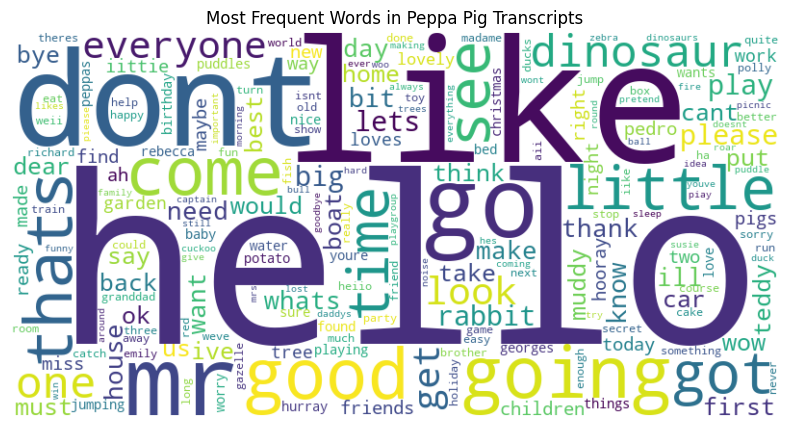

In [50]:
# Calculate frequency distribution
fdist = FreqDist(filtered_tokens)

# Print the 100 most common words
print("--- Top 220 Most Common Words ---")
print(fdist.most_common(220))

# --- Generate and display a Word Cloud ---
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(fdist)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Peppa Pig Transcripts')
plt.show()


In [52]:
# Dolch Sight Words list for Pre-K (40 words)
dolch_prek_list = {
    'a', 'about', 'after', 'again', 'all', 'always', 'am', 'an', 'and', 'any', 
    'apple', 'are', 'around', 'as', 'ask', 'at', 'ate', 'away', 'baby', 'back', 
    'ball', 'be', 'bear', 'because', 'bed', 'been', 'before', 'bell', 'best', 
    'better', 'big', 'bird', 'birthday', 'black', 'blue', 'boat', 'both', 
    'box', 'boy', 'bread', 'bring', 'brother', 'brown', 'but', 'buy', 'by', 
    'cake', 'call', 'came', 'can', 'car', 'carry', 'cat', 'chair', 'chicken', 
    'children', 'christmas', 'clean', 'coat', 'cold', 'come', 'corn', 'could', 
    'cow', 'cut', 'day', 'did', 'do', 'does', 'dog', 'doll', 'dont', 'door', 
    'down', 'draw', 'drink', 'duck', 'eat', 'egg', 'eight', 'every', 'eye', 
    'fall', 'far', 'farm', 'farmer', 'fast', 'father', 'feet', 'find', 'fire', 
    'first', 'fish', 'five', 'floor', 'flower', 'fly', 'for', 'found', 'four', 
    'from', 'full', 'funny', 'game', 'garden', 'gave', 'get', 'girl', 'give', 
    'go', 'goes', 'going', 'good', 'goodbye', 'got', 'grass', 'green', 'ground', 
    'grow', 'had', 'hand', 'has', 'have', 'he', 'head', 'help', 'her', 'here', 
    'hill', 'him', 'his', 'hold', 'home', 'horse', 'hot', 'house', 'how', 
    'hurt', 'i', 'if', 'in', 'into', 'is', 'it', 'its', 'jump', 'just', 
    'keep', 'kind', 'kitty', 'know', 'laugh', 'leg', 'let', 'letter', 'light', 
    'like', 'little', 'live', 'long', 'look', 'made', 'make', 'man', 'many', 
    'may', 'me', 'men', 'milk', 'money', 'morning', 'mother', 'much', 'must', 
    'my', 'myself', 'name', 'nest', 'never', 'new', 'night', 'no', 'not', 
    'now', 'of', 'off', 'old', 'on', 'once', 'one', 'only', 'open', 'or', 
    'our', 'out', 'over', 'own', 'paper', 'party', 'pick', 'picture', 'pig', 
    'play', 'please', 'pretty', 'pull', 'put', 'rabbit', 'rain', 'ran', 
    'read', 'red', 'ride', 'right', 'ring', 'robin', 'round', 'run', 'said', 
    'santa', 'claus', 'saw', 'say', 'school', 'see', 'seed', 'seven', 'shall', 
    'she', 'sheep', 'shoe', 'show', 'sing', 'sister', 'sit', 'six', 'sleep', 
    'small', 'snow', 'so', 'some', 'song', 'soon', 'squirrel', 'start', 
    'stick', 'stop', 'street', 'sun', 'table', 'take', 'tell', 'ten', 'thank', 
    'that', 'the', 'their', 'them', 'then', 'there', 'these', 'they', 'thing', 
    'think', 'this', 'those', 'three', 'time', 'to', 'today', 'together', 
    'too', 'top', 'toy', 'tree', 'try', 'two', 'under', 'up', 'upon', 'us', 
    'use', 'very', 'walk', 'want', 'warm', 'was', 'wash', 'watch', 'water', 
    'way', 'we', 'well', 'went', 'were', 'what', 'when', 'where', 'which', 
    'white', 'who', 'why', 'will', 'wind', 'window', 'wish', 'with', 'wood', 
    'work', 'would', 'write', 'yellow', 'yes', 'you', 'your'
}

# Get the unique set of words from our Peppa Pig text
peppa_vocabulary = set(filtered_tokens)

# Find the words that are in both lists
common_words = peppa_vocabulary.intersection(dolch_prek_list)

# Calculate the percentage of overlap
# This tells us how many of the benchmark words appear in Peppa Pig
overlap_percentage = (len(common_words) / len(dolch_prek_list)) * 100

print(f"Peppa Pig seaon 1-4 use {len(common_words)} out of {len(dolch_prek_list)} Pre-K Dolch words.")
print(f"That's an overlap of {overlap_percentage:.2f}%.")

# Analyze the most common Peppa Pig words NOT in the Dolch list
top_words_series = pd.Series(fdist)
non_dolch_words = top_words_series.drop(labels=dolch_prek_list, errors='ignore').sort_values(ascending=False)

print("\n--- Top 100 Common Words in Peppa Pig NOT on the Dolch Pre-K list ---")
print(non_dolch_words.head(100))


Peppa Pig seaon 1-4 use 208 out of 315 Pre-K Dolch words.
That's an overlap of 66.03%.

--- Top 100 Common Words in Peppa Pig NOT on the Dolch Pre-K list ---
hello       438
mr          319
thats       265
dinosaur    227
everyone    221
           ... 
piease       48
coming       48
doesnt       48
still        47
hard         47
Length: 100, dtype: int64
